In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import seaborn as sns
from scipy import stats

# 3. Plotting & pandas options
plt.rcParams['figure.figsize'] = (10,5)
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

# 4. Paths & constants
COUNTRY = "benin-malanville"
RAW_PATH = "/content/drive/MyDrive/data/data"  # path to folder containing your CSV
DATA_DIR = "/content/drive/MyDrive/data_clean"  # folder to save cleaned CSV
os.makedirs(DATA_DIR, exist_ok=True)

INPUT_CSV = f"{RAW_PATH}/{COUNTRY}.csv"
CLEAN_CSV = f"{DATA_DIR}/{COUNTRY}_clean.csv"

# 5. Load data
df = pd.read_csv(INPUT_CSV, low_memory=False)
print("rows, cols:", df.shape)
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/data/data/benin-malanville.csv'

In [ ]:
# 3. Parse timestamp & dtypes
possible_ts_cols = [c for c in df.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
print("Possible timestamp columns:", possible_ts_cols)
# replace 'Timestamp' below with your column name if different
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce', format="%Y-%m-%d %H:%M")
# set index for time-series plotting
df = df.sort_values('Timestamp').reset_index(drop=True)


Possible timestamp columns: ['Timestamp']


In [ ]:
# 4. Summary statistics & missing-value report
display(df.info())
display(df.describe().T)

# missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.concat([missing, missing_pct], axis=1)
missing_report.columns = ['missing_count', 'missing_pct']
display(missing_report[missing_report['missing_pct']>0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[ns]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  int64         
 14  Cleaning       525600 non-null  int64         
 15  

None

,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-02-07 12:00:30.000000512,2021-08-09 00:01:00,2021-11-08 06:00:45,2022-02-07 12:00:30,2022-05-09 18:00:15,2022-08-09 00:00:00,NaN
GHI,525600.000,240.559,-12.900,-2.000,1.800,483.400,1413.000,331.131
DNI,525600.000,167.188,-7.800,-0.500,-0.100,314.200,952.300,261.711
DHI,525600.000,115.359,-12.600,-2.100,1.600,216.300,759.200,158.691
ModA,525600.000,236.589,0.000,0.000,4.500,463.700,1342.300,326.895
ModB,525600.000,228.884,0.000,0.000,4.300,447.900,1342.300,316.537
Tamb,525600.000,28.180,11.000,24.200,28.000,32.300,43.800,5.924
RH,525600.000,54.488,2.100,28.800,55.100,80.100,100.000,28.073
WS,525600.000,2.121,0.000,1.000,1.900,3.100,19.500,1.603
WSgust,525600.000,2.809,0.000,1.300,2.600,4.100,26.600,2.029


,missing_count,missing_pct
Comments,525600,100.000


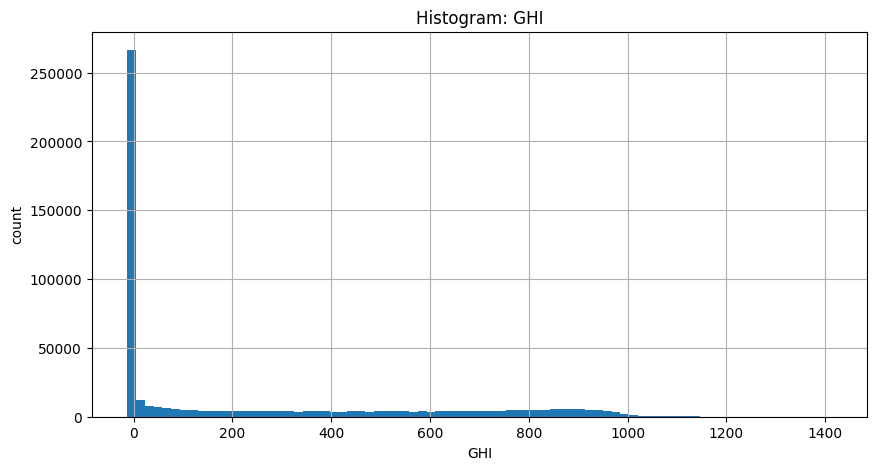

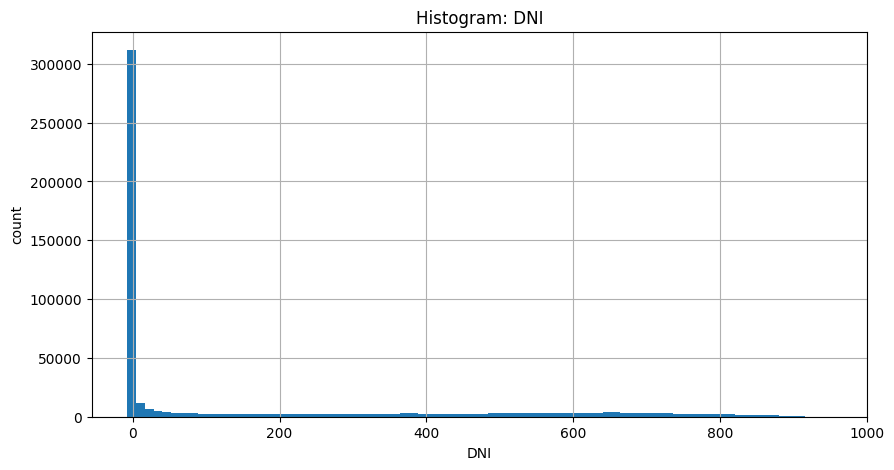

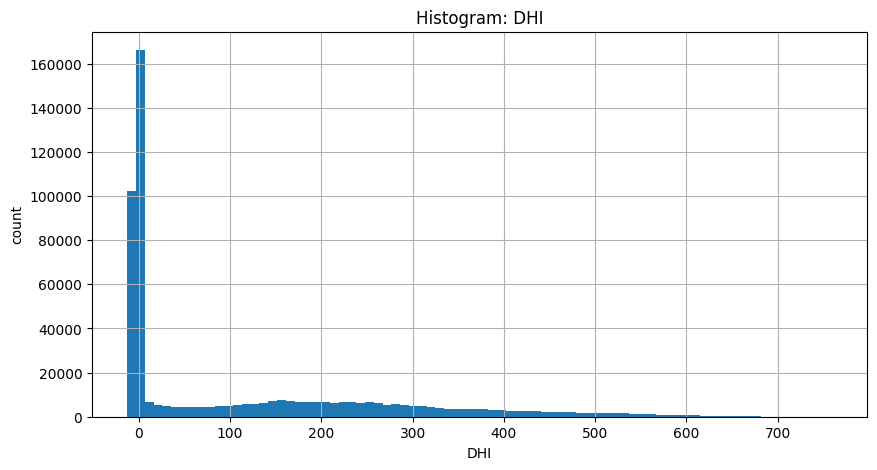

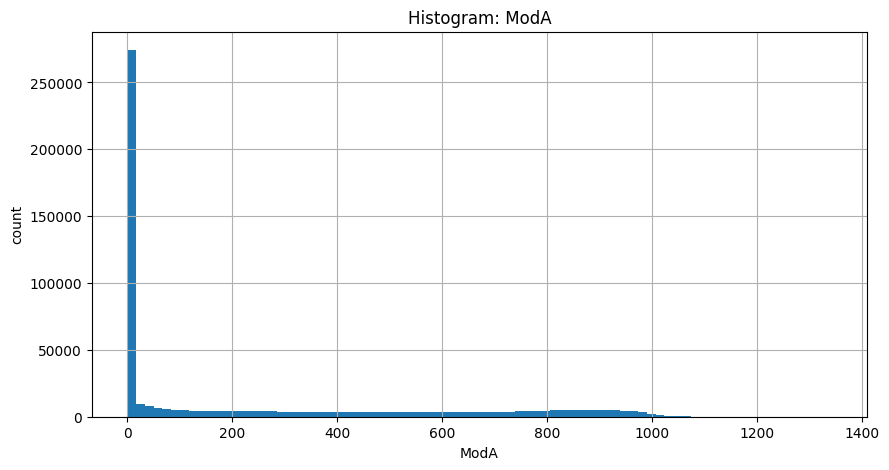

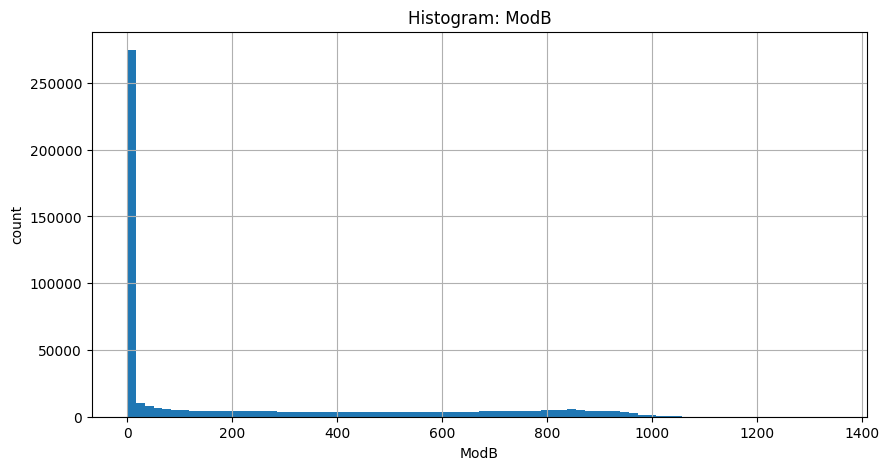

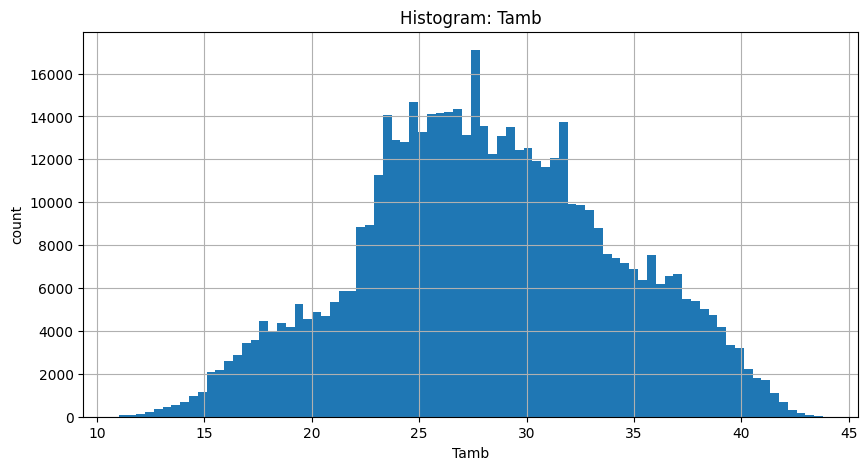

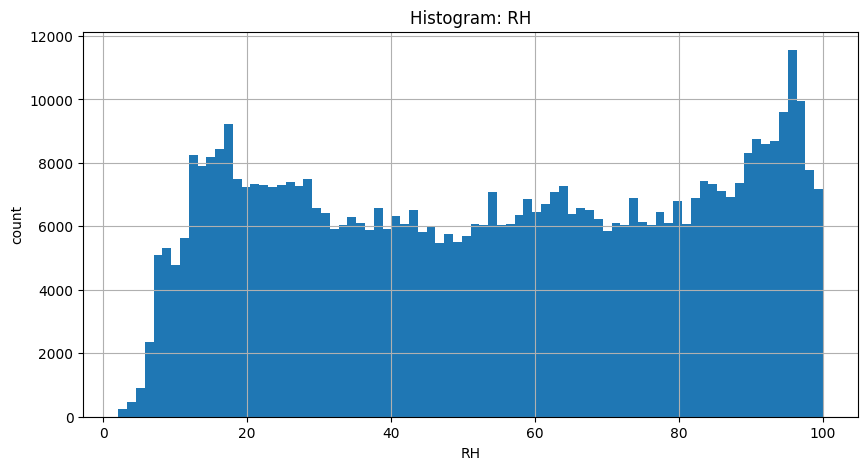

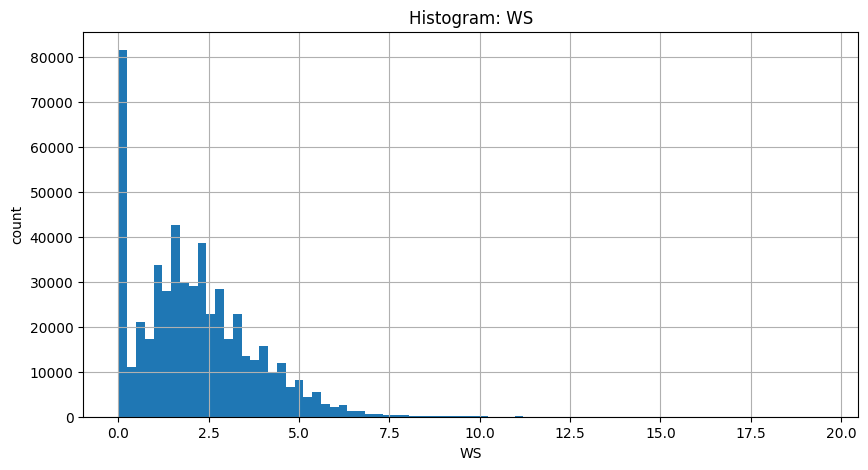

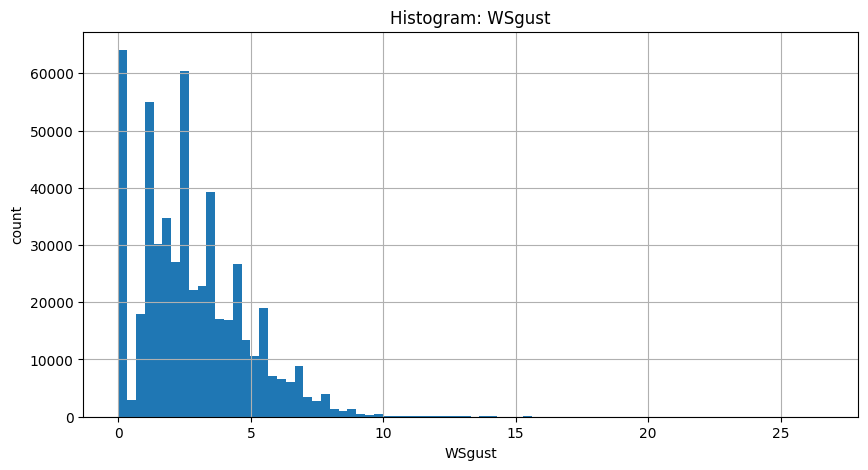

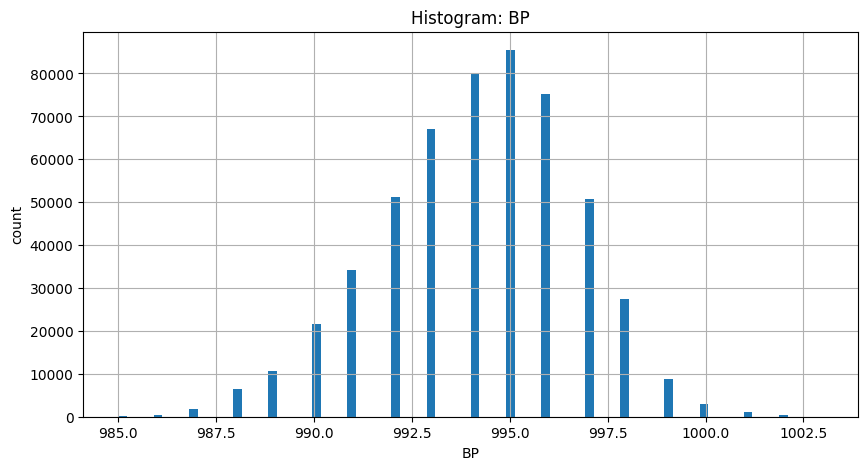

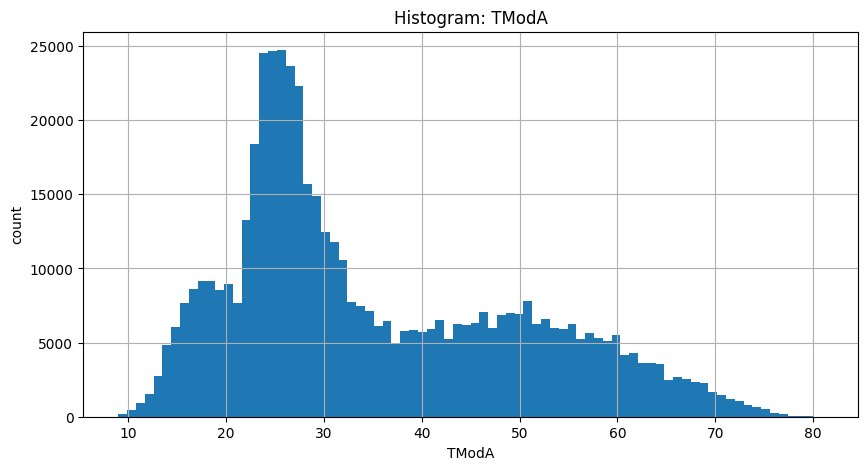

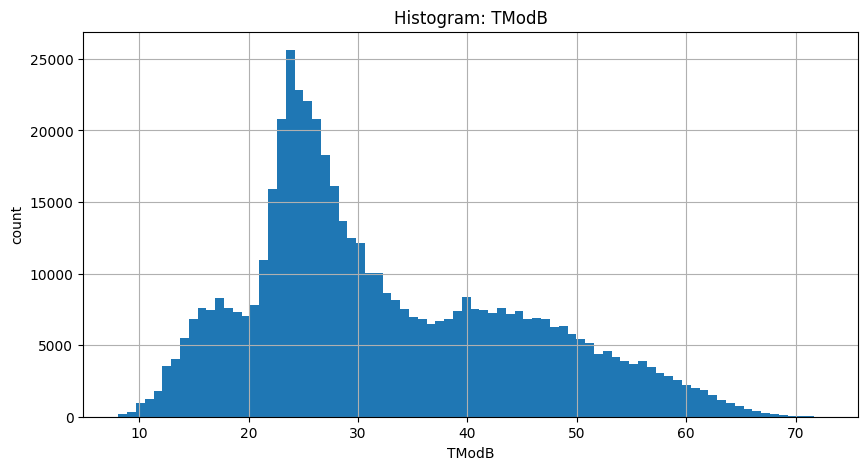

In [ ]:
# 5. Quick histograms for key vars
numeric = df.select_dtypes(include=[np.number]).columns.tolist()
key_vars = ['GHI','DNI','DHI','ModA','ModB','Tamb','RH','WS','WSgust','BP','TModA','TModB']
vars_plot = [v for v in key_vars if v in df.columns]
for v in vars_plot:
    plt.figure()
    df[v].hist(bins=80)
    plt.title(f"Histogram: {v}")
    plt.xlabel(v)
    plt.ylabel("count")
    plt.show()


In [ ]:
# 6. Outlier detection using Z-score
z_cols = [c for c in ['GHI','DNI','DHI','ModA','ModB','WS','WSgust'] if c in df.columns]
z_thresh = 3.0
outlier_mask = pd.Series(False, index=df.index)
for c in z_cols:
    col = df[c].dropna()
    z = np.abs(stats.zscore(col))
    # stats.zscore returned array aligned to col.index, need to map back
    z_full = pd.Series(index=col.index, data=z)
    outlier_mask.loc[z_full.index] = outlier_mask.loc[z_full.index] | (z_full > z_thresh)

print("Total rows with any z>|3| on selected columns:", outlier_mask.sum())
# optional: show some outliers
display(df.loc[outlier_mask].head(10))


Total rows with any z>|3| on selected columns: 7740


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
670,2021-08-09 11:11:00,836.000,235.000,610.600,778.800,783.800,30.300,68.200,3.200,4.100,0.700,190.500,18.400,999,0,0.000,63.000,52.700,NaN
671,2021-08-09 11:12:00,1274.000,698.800,615.200,1210.300,1210.300,30.100,69.600,3.400,4.100,0.600,175.800,13.300,999,0,0.000,63.700,53.100,NaN
672,2021-08-09 11:13:00,938.000,340.100,612.800,891.100,891.100,30.400,68.400,3.400,4.600,0.900,171.500,11.900,999,0,0.000,65.800,54.300,NaN
673,2021-08-09 11:14:00,718.500,126.800,593.200,682.600,682.600,30.600,68.200,4.700,5.600,0.600,160.700,8.000,999,0,0.000,65.400,54.200,NaN
674,2021-08-09 11:15:00,1349.000,771.800,618.000,1281.500,1281.500,30.900,67.100,4.000,4.600,0.400,169.100,12.300,999,0,0.000,65.000,53.500,NaN
675,2021-08-09 11:16:00,792.600,169.500,625.400,753.000,753.000,31.100,66.700,3.600,4.400,0.500,175.500,18.900,999,0,0.000,65.800,53.600,NaN
676,2021-08-09 11:17:00,1334.000,751.900,620.000,1267.300,1267.300,31.100,67.000,2.700,3.600,0.600,208.000,15.900,999,0,0.000,66.000,53.900,NaN
677,2021-08-09 11:18:00,943.000,351.500,602.800,846.000,850.000,31.000,67.900,3.100,4.100,0.600,181.000,8.900,999,0,0.000,67.800,55.100,NaN
717,2021-08-09 11:58:00,758.900,149.200,601.200,709.900,713.800,30.100,69.200,3.100,3.900,0.600,207.800,19.500,999,0,0.000,55.600,47.900,NaN
718,2021-08-09 11:59:00,632.800,23.000,603.300,587.000,591.000,30.200,69.300,3.000,4.100,0.700,211.100,22.600,999,0,0.000,56.400,48.400,NaN


In [ ]:
# 7. Strategy for outliers/missing: Example - median impute on key columns
# Document: we will median-impute for sensor & irradiance columns, drop rows with missing timestamp
drop_rows_before = len(df)
df = df.dropna(subset=['Timestamp'])   # must have timestamp
print("Dropped rows without timestamp:", drop_rows_before - len(df))

impute_cols = [c for c in ['GHI','DNI','DHI','ModA','ModB','Tamb','RH','WS'] if c in df.columns]
for c in impute_cols:
    median_val = df[c].median()
    df[c] = df[c].fillna(median_val)
    # optional: cap extreme outliers by winsorizing at 1st/99th percentile
    lower, upper = df[c].quantile([0.01, 0.99])
    df[c] = df[c].clip(lower=lower, upper=upper)


Dropped rows without timestamp: 0


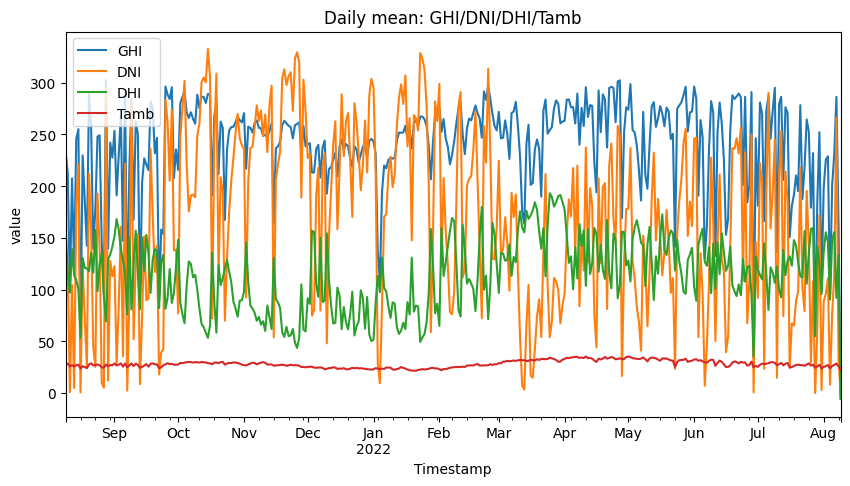

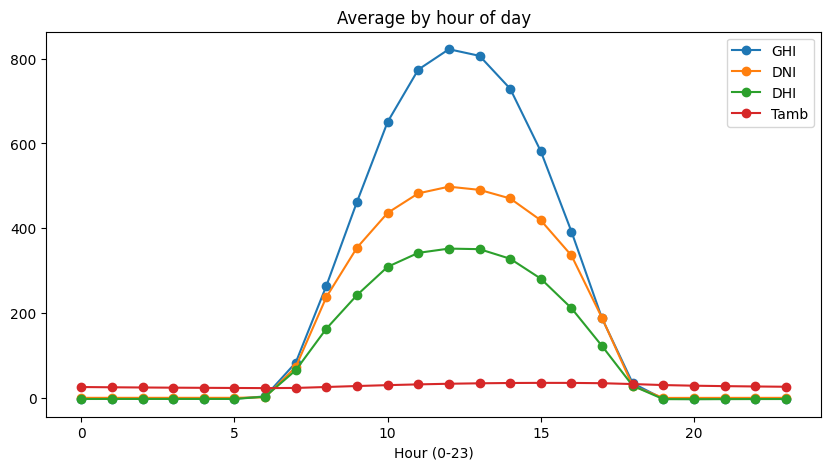

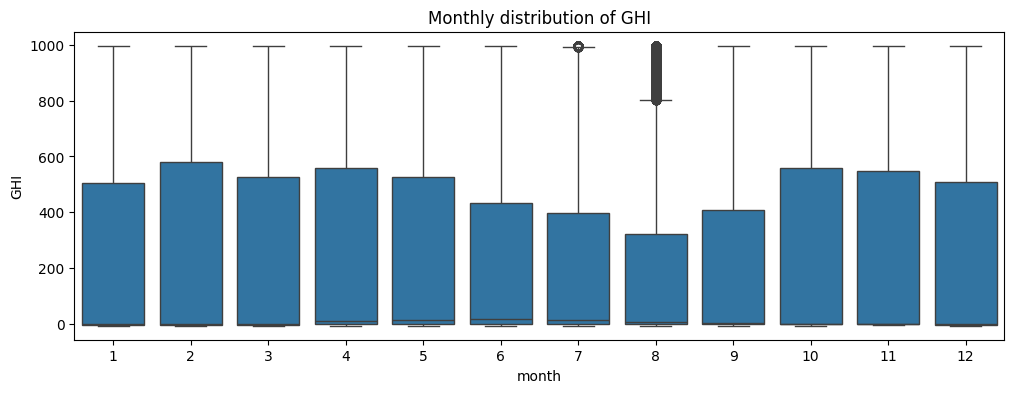

In [ ]:
# 8. Time-series plots (daily pattern & monthly)
if 'Timestamp' in df.columns:
    df.set_index('Timestamp', inplace=True)
    # rolling daily mean for example
    plot_cols = [c for c in ['GHI','DNI','DHI','Tamb'] if c in df.columns]
    df[plot_cols].resample('D').mean().plot(subplots=False)
    plt.title("Daily mean: GHI/DNI/DHI/Tamb")
    plt.ylabel("value")
    plt.show()

    # diurnal pattern: average by hour of day
    df['hour'] = df.index.hour
    hourly = df.groupby('hour')[plot_cols].mean()
    hourly.plot(marker='o')
    plt.title("Average by hour of day")
    plt.xlabel("Hour (0-23)")
    plt.show()

    # monthly boxplot for GHI (if long range)
    if 'GHI' in df.columns:
        df['month'] = df.index.month
        import seaborn as sns
        plt.figure(figsize=(12,4))
        sns.boxplot(x='month', y='GHI', data=df.reset_index())
        plt.title("Monthly distribution of GHI")
        plt.show()
    # reset index if you prefer not to keep it
    df.reset_index(inplace=True)


,ModA,ModB
Cleaning,,
0,236.165,228.385
1,307.229,301.972


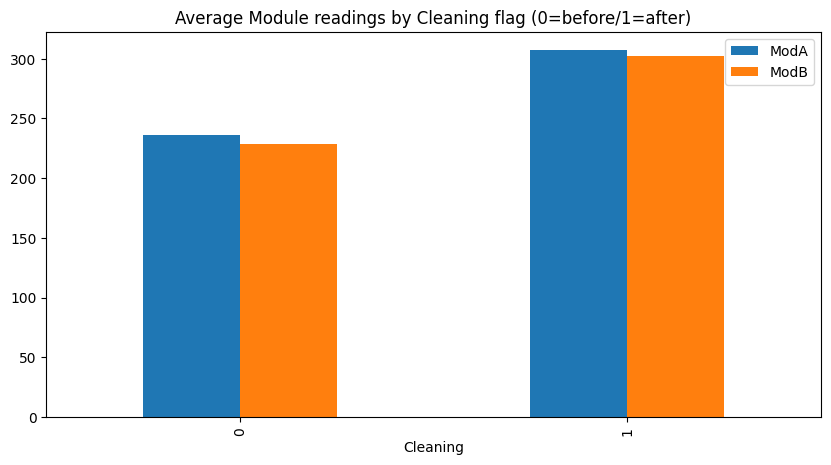

In [ ]:
# 9. Cleaning impact (compare ModA/ModB pre/post cleaning)
if 'Cleaning' in df.columns and 'ModA' in df.columns:
    # ensure Cleaning is binary 0/1
    df['Cleaning'] = df['Cleaning'].astype(int)
    grouped = df.groupby('Cleaning')[['ModA','ModB']].mean()
    display(grouped)
    grouped.plot(kind='bar')
    plt.title("Average Module readings by Cleaning flag (0=before/1=after)")
    plt.show()


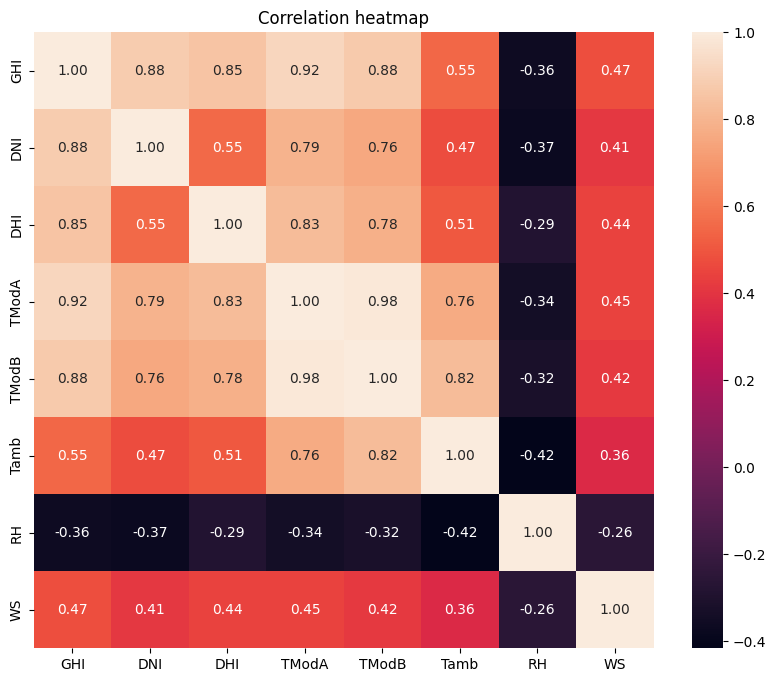

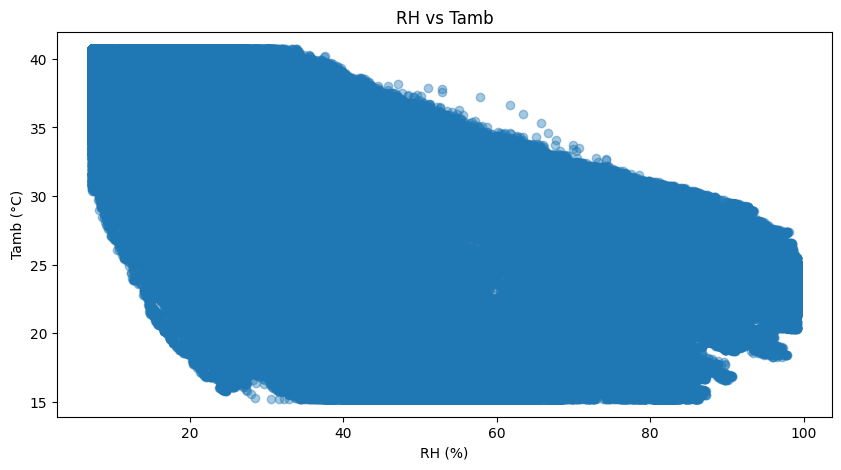

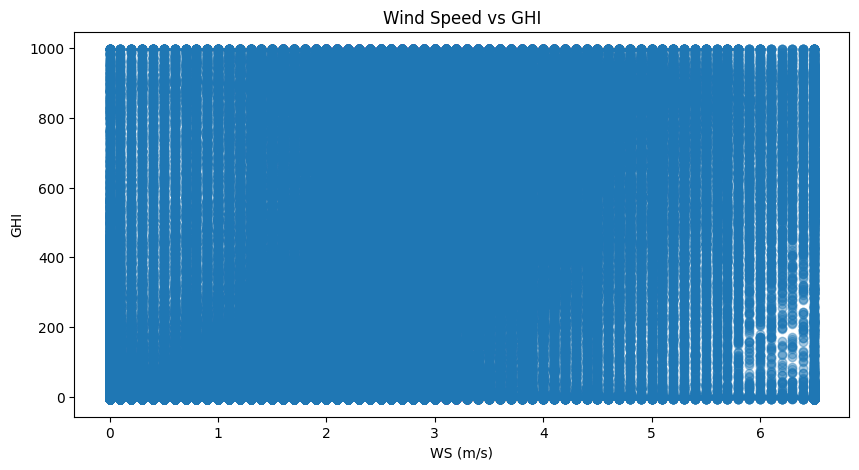

In [ ]:
# 10. Correlation & scatterplots
corr_cols = [c for c in ['GHI','DNI','DHI','TModA','TModB','Tamb','RH','WS'] if c in df.columns]
plt.figure(figsize=(10,8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

# scatter: RH vs Tamb and WS vs GHI
if 'RH' in df.columns and 'Tamb' in df.columns:
    plt.figure()
    plt.scatter(df['RH'], df['Tamb'], alpha=0.4)
    plt.xlabel('RH (%)'); plt.ylabel('Tamb (°C)'); plt.title('RH vs Tamb')
    plt.show()
if 'WS' in df.columns and 'GHI' in df.columns:
    plt.figure()
    plt.scatter(df['WS'], df['GHI'], alpha=0.4)
    plt.xlabel('WS (m/s)'); plt.ylabel('GHI'); plt.title('Wind Speed vs GHI')
    plt.show()


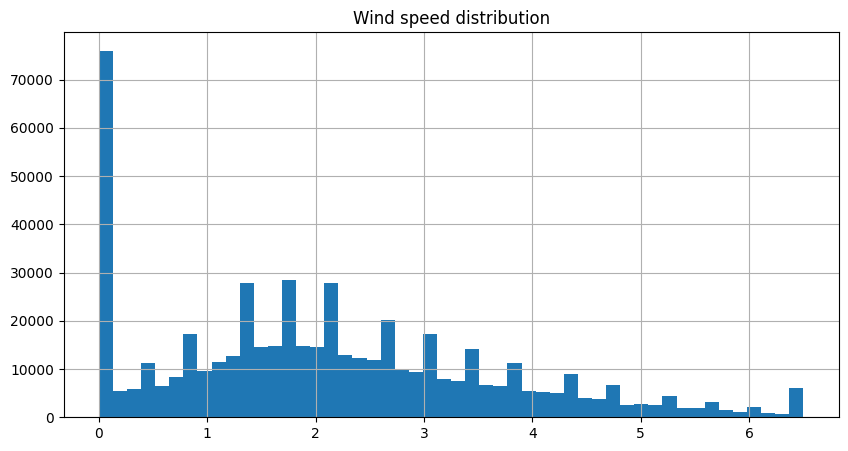

,count
wd_sector,
N,106903
NE,80268
E,41973
SE,32505
S,98651
SW,109635
W,30838
NW,24827


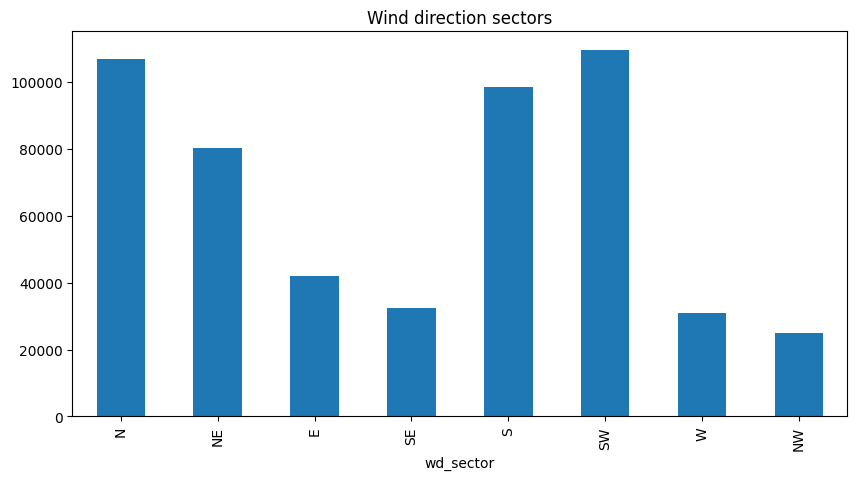

In [ ]:
# 11. Wind analysis: histograms & simple directional summary
if 'WS' in df.columns:
    df['WS'].hist(bins=50)
    plt.title("Wind speed distribution")
    plt.show()
if 'WD' in df.columns:
    # simple binned wind direction counts
    bins = np.arange(0, 360+45, 45)  # 8 sectors
    labels = ["N","NE","E","SE","S","SW","W","NW"]
    df['wd_sector'] = pd.cut(df['WD'] % 360, bins=bins, labels=labels, right=False)
    display(df['wd_sector'].value_counts().sort_index())
    df['wd_sector'].value_counts().sort_index().plot(kind='bar')
    plt.title("Wind direction sectors")
    plt.show()


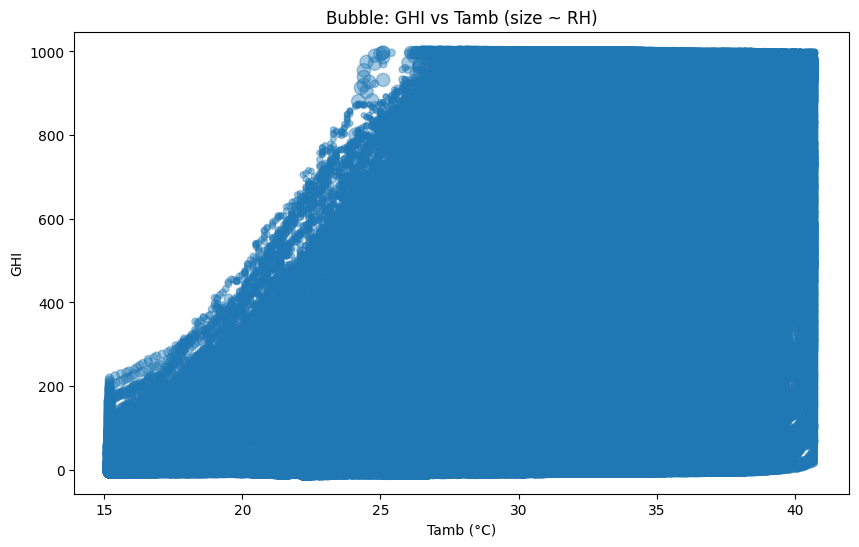

In [ ]:
# 12. Bubble chart: GHI vs Tamb, bubble size = RH
if all(c in df.columns for c in ['GHI','Tamb','RH']):
    plt.figure(figsize=(10,6))
    plt.scatter(df['Tamb'], df['GHI'], s=(df['RH'].clip(1,100)), alpha=0.4)
    plt.xlabel("Tamb (°C)"); plt.ylabel("GHI")
    plt.title("Bubble: GHI vs Tamb (size ~ RH)")
    plt.show()


In [ ]:
# 13. Save cleaned CSV (to data/ but DO NOT commit it)
df.to_csv(CLEAN_CSV, index=False)
print("Saved cleaned CSV to:", CLEAN_CSV)


Saved cleaned CSV to: /content/drive/MyDrive/data_clean/benin-malanville_clean.csv
